In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Patch
from scipy.spatial import ConvexHull

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
bfont_path = "/usr/share/fonts/myFonts/arialbd.ttf"
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_prop_7 = FontProperties(fname=font_path, size=7)
font_name = font_prop.get_name()
ifont_prop = FontProperties(fname=ifont_path)
ifont_prop_7 = FontProperties(fname=ifont_path, size=7)
ifont_prop_6 = FontProperties(fname=ifont_path, size=6.5)
bfont_prop = FontProperties(fname=bfont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]

In [2]:
base_folder = '/active-data/analysis_results/chr_pla/genus'
genus_name = 'Escherichia'
random_seed = 42
model_list = [
    ("evo2_mean", "Evo2"),
    ("glm2_mean", "gLM2"),
    ("nt_mean", "Nucleotide Transformer")
]
categories = [
    'typical plasmid',
    'intermediate replicon',
    'chromosome fragment',
    'typical chromosome'
]
cat_label = [
    'IR',
    'Typical\nplasmid',
    'Chromosomal\nfragment',
    'Typical\nchromosome'
]
cat_legend_full = [
    'Typical plasmid',
    'Intermediate replicon (IR)',
    'Chromosomal fragment',
    'Typical chromosome'
]
group_color_map = {
    'typical plasmid': plt.cm.tab10(0),
    'intermediate replicon': "#32CD32",
    'chromosome fragment': plt.cm.tab10(1),
    'typical chromosome': plt.cm.tab10(3)
}

def get_cell_color(r_val):
    if r_val <= 0.25:
        return '#f0f7fb'
    elif r_val <= 0.50:
        return '#b3d8eb'
    elif r_val <= 0.75:
        return '#5a9fd1'
    else:
        return '#1864ab'

def get_sig_star(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

def plot_pca_scatter(ax, pca_df, explained_var, title):
    for cat in categories:
        sub = pca_df[pca_df["category-pident_90"] == cat]
        pts = sub[["PC1","PC2"]].values
        if len(pts) >=3:
            hull = ConvexHull(pts)
            ax.fill(pts[hull.vertices,0], pts[hull.vertices,1], color=group_color_map[cat], alpha=0.15)

    pca_df["_point_color"] = pca_df["category-pident_90"].map(group_color_map)
    df_shuffled = pca_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)
    
    ax.scatter(
        df_shuffled["PC1"],
        df_shuffled["PC2"],
        c=df_shuffled["_point_color"],
        alpha=0.7,
        s=5
    )

    ax.set_xlabel(f"PC1 ({explained_var[0]:.2%})")
    ax.set_ylabel(f"PC2 ({explained_var[1]:.2%})")
    ax.set_title(title)

def plot_anosim_matrix(ax, r_matrix, p_matrix, title):
    n_group = len(categories)
    ax.set_xlim(-0.5, n_group-0.5)
    ax.set_ylim(-0.5, n_group-0.5)
    ax.set_xticks(np.arange(n_group))
    ax.set_yticks(np.arange(n_group))
    ax.set_xticklabels(cat_label, rotation=0, ha="center", fontsize=6.5)
    ax.set_yticklabels(cat_label, fontsize=6.5)
    ax.tick_params(axis='y', pad=0)
    ax.invert_yaxis()

    for i in range(n_group):
        for j in range(n_group):
            r = r_matrix[i,j]
            p = p_matrix[i,j]
            if i >= j:
                rect = plt.Rectangle((j-0.5, i-0.5), width=1, height=1, color=get_cell_color(r), ec="white", lw=1.2)
                ax.add_patch(rect)
                if i == j:
                    ax.text(j, i, "-", ha="center", va="center", c="#666666")
                else:
                    star = get_sig_star(p)
                    text_content = f"{r:.3f}\n{star}"
                    ax.text(j, i, text_content, ha="center", va="center")

    ax.set_title(title)

storage = []
for model_dir_name, plot_title in model_list:
    target_dir = f'{base_folder}/embedding_vector/{genus_name}/{model_dir_name}'
    vector_dir = f"{target_dir}/random_seed_{random_seed}"

    pca_df = pd.read_csv(f"{vector_dir}_pca_2d.tsv", sep='\t')
    anosim_df = pd.read_csv(f"{vector_dir}_anosim_highdim_euclidean_result.tsv", sep='\t')
    comps = np.load(f"{vector_dir}_pca_2d_components.npy")
    explained = np.load(f"{vector_dir}_pca_explained.npy")

    n_cat = len(categories)
    r_mat = np.zeros((n_cat, n_cat))
    p_mat = np.zeros((n_cat, n_cat))
    for _, row in anosim_df.iterrows():
        g1 = row["group1"]
        g2 = row["group2"]
        i = categories.index(g1)
        j = categories.index(g2)
        r_mat[i,j] = row["anosim_R_highdim_euclidean"]
        r_mat[j,i] = row["anosim_R_highdim_euclidean"]
        p_mat[i,j] = row["anosim_pvalue"]
        p_mat[j,i] = row["anosim_pvalue"]

    storage.append({
        "title": plot_title,
        "pca_df": pca_df,
        "explained": explained,
        "r_mat": r_mat,
        "p_mat": p_mat
    })

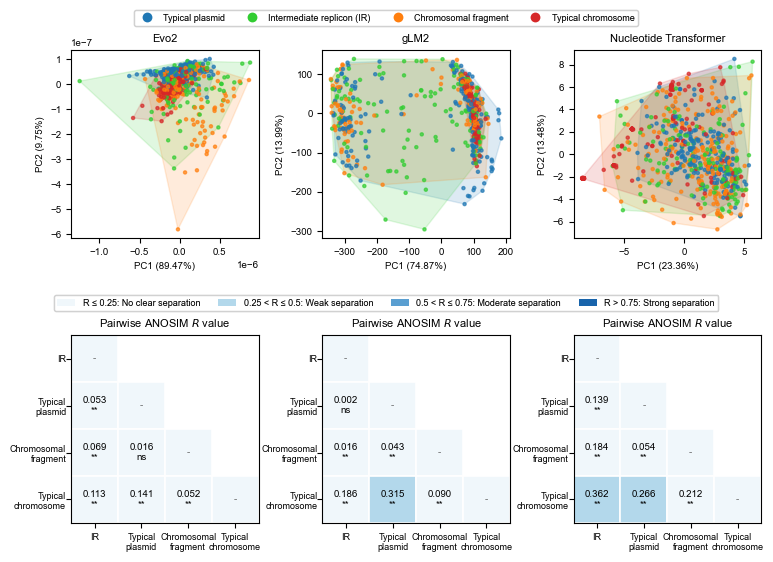

In [3]:
fig = plt.figure(figsize=(7.5, 7.5))
rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

w_step = 0.335
x_start = 0.08
y_pca_top = 0.69
y_mat_top = 0.31
ax_h = 0.25

for col_idx, data in enumerate(storage):
    x0 = x_start + col_idx * w_step
    ax_pca = fig.add_axes([x0, y_pca_top, ax_h, ax_h])
    plot_pca_scatter(
        ax=ax_pca,
        pca_df=data["pca_df"],
        explained_var=data["explained"],
        title=f'{data["title"]}' #\n2D PCA Embedding'
    )

    ax_mat = fig.add_axes([x0, y_mat_top, ax_h, ax_h])
    plot_anosim_matrix(
        ax=ax_mat,
        r_matrix=data["r_mat"],
        p_matrix=data["p_mat"],
        title=r'Pairwise ANOSIM $\mathit{R}$ value' #+'\n(High-dimensional, Euclidean)'
    )

category_legend_elems = []
for cat, leg_text in zip(categories, cat_legend_full):
    category_legend_elems.append(
        plt.Line2D([], [], marker='o', linestyle='', color=group_color_map[cat], markersize=6, label=leg_text)
    )

r_legend_elems = [
    Patch(facecolor="#f0f7fb", label="R ≤ 0.25: No clear separation"),
    Patch(facecolor="#b3d8eb", label="0.25 < R ≤ 0.5: Weak separation"),
    Patch(facecolor="#5a9fd1", label="0.5 < R ≤ 0.75: Moderate separation"),
    Patch(facecolor="#1864ab", label="R > 0.75: Strong separation")
]

leg_cat = fig.legend(
    handles=category_legend_elems,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1),
    frameon=True
)
fig.add_artist(leg_cat)

leg_r = fig.legend(
    handles=r_legend_elems,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.62),
    frameon=True
)
fig.add_artist(leg_r)

figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_fundamental_model_embedding_vector_results.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_fundamental_model_embedding_vector_results.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()